# Exp0.1.5 — WholeCount firing-pattern diagnostic

Checkpoint-only analysis for `experiment_0_1_5_gradient_calibrated_all_fixes`. **This notebook never trains, backpropagates, or updates weights.**

Fixed comparison:
- objective: `whole_count_ce`
- variant: binary, hidden cap = 1, output cap = 1
- architectures: `short_mid`, `mid_long`, `short_mid_long`
- same Exp0.1 split seed, same test segment for all three architectures
- each architecture uses its validation-selected Exp0.1.5 gradient-ratio checkpoint

All dynamics are traced across the **original full padded window**. The red dashed line is the original `valid_length`; everything to the right is padding and is diagnostic only. Native WholeCount prediction still sums only the valid interval.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_VERSION = 'exp015_wholecount_firing_patterns_v1_20260910'
start = Path.cwd().resolve()
repo_root = next((p for p in (start, *start.parents) if (p / 'scripts').is_dir() and (p / 'notebooks').is_dir()), None)
if repo_root is None:
    raise RuntimeError(f'Could not locate writingRing repo root from cwd={start}')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from IPython.display import display

from scripts import experiment_0_1_5_gradient_calibrated_all_fixes as exp015

def to_numpy(tensor):
    return tensor.detach().cpu().numpy()

print('NOTEBOOK_VERSION:', NOTEBOOK_VERSION)
print('repo_root:', repo_root)
print('Exp0.1.5 import: OK')

NOTEBOOK_VERSION: exp015_wholecount_firing_patterns_v1_20260910
repo_root: /home/zhaolongwei_umass_edu/projects/writingRing
Exp0.1.5 import: OK


## Configuration

`TARGET_GRAD_RATIO_OVERRIDE=None` selects, independently for each architecture, the available Exp0.1.5 checkpoint with highest stored validation WholeCount BA, tie-broken by lower validation WholeCount CE. Set a float such as `0.10` only if you intentionally want the same regularizer target for all three architectures.

If `SAMPLE_INDEX=None`, the notebook prefers a test segment where `short_mid` is correct and at least one architecture containing the long `(6,7)` scales is wrong; otherwise it falls back to any prediction disagreement, then sample 0.

In [2]:
OBJECTIVE = 'whole_count_ce'
ARCHITECTURES = ('short_mid', 'mid_long', 'short_mid_long')
SEED = 11
TARGET_GRAD_RATIO_OVERRIDE = None
SAMPLE_INDEX = None
DEVICE = 'cpu'
BATCH_SIZE = 128
SAVE_FIGURES = False

if OBJECTIVE != 'whole_count_ce':
    raise ValueError('This diagnostic is intentionally fixed to whole_count_ce')
if tuple(ARCHITECTURES) != ('short_mid', 'mid_long', 'short_mid_long'):
    raise ValueError('This notebook is designed for the three agreed architecture cases')

results_root = exp015.results_dir(repo_root)
config = exp015.Config(
    repo_root=repo_root,
    results_dir=results_root,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    threads=1,
)
device = torch.device(DEVICE)
data = exp015.exp01.prepare_data(repo_root)
X, y, lengths = data.Xte, data.yte, data.lte
FULL_T = int(X.shape[1])

print('test samples:', len(X))
print('full padded T:', FULL_T)
print('sampling rate:', data.fs, 'Hz')
print('architectures:', {k: exp015.DIRECT_ARCHITECTURES[k] for k in ARCHITECTURES})

test samples: 146
full padded T: 256
sampling rate: 64.0 Hz
architectures: {'short_mid': ((2, 3), (2, 3, 4, 5)), 'mid_long': ((2, 3, 4, 5), (2, 3, 4, 5, 6, 7)), 'short_mid_long': ((2, 3), (2, 3, 4, 5), (2, 3, 4, 5, 6, 7))}


## Select and load existing checkpoints only

No checkpoint is created in this notebook. Missing checkpoints are treated as an error. Selection uses checkpoint metadata only; test performance is not used to choose the gradient ratio.

In [3]:
def make_spec(architecture, ratio):
    return exp015.RunSpec(float(ratio), architecture, OBJECTIVE, SEED)

def select_spec(architecture):
    if TARGET_GRAD_RATIO_OVERRIDE is not None:
        ratios = (float(TARGET_GRAD_RATIO_OVERRIDE),)
    else:
        ratios = tuple(float(v) for v in exp015.TARGET_GRAD_RATIOS)
    candidates = []
    missing = []
    for ratio in ratios:
        spec = make_spec(architecture, ratio)
        path = exp015.checkpoint_path(results_root, spec)
        if not path.exists():
            missing.append(str(path))
            continue
        checkpoint = torch.load(path, map_location='cpu', weights_only=False)
        candidates.append((
            spec,
            float(checkpoint['best_val_wholecount_ba']),
            float(checkpoint['best_val_wholecount_loss']),
            int(checkpoint['best_epoch']),
            path,
        ))
    if not candidates:
        raise FileNotFoundError('No matching Exp0.1.5 checkpoint for ' + architecture + '\n' + '\n'.join(missing))
    candidates.sort(key=lambda row: (-row[1], row[2], row[0].target_grad_ratio))
    return candidates[0], candidates

selected = {}
selection_rows = []
for architecture in ARCHITECTURES:
    best, candidates = select_spec(architecture)
    spec, val_ba, val_loss, best_epoch, path = best
    model, checkpoint = exp015.load_model(spec, data, config)
    model.eval()
    selected[architecture] = {'spec': spec, 'model': model, 'checkpoint': checkpoint, 'path': path}
    selection_rows.append({
        'architecture': architecture,
        'target_grad_ratio': spec.target_grad_ratio,
        'best_val_wholecount_ba': val_ba,
        'best_val_wholecount_loss': val_loss,
        'best_epoch': best_epoch,
        'checkpoint': path.name,
        'all_available_candidates': '; '.join(
            f'gr={row[0].target_grad_ratio:.2f}:BA={row[1]:.4f},CE={row[2]:.4f}' for row in candidates
        ),
    })
selection_table = pd.DataFrame(selection_rows)
display(selection_table)

,architecture,target_grad_ratio,best_val_wholecount_ba,best_val_wholecount_loss,best_epoch,checkpoint,all_available_candidates
0,short_mid,0.05,0.422373,1.781393,97,direct_snn__short_mid__whole_count_ce__binary_...,"gr=0.05:BA=0.4224,CE=1.7814; gr=0.10:BA=0.4131..."
1,mid_long,0.05,0.354443,1.987413,99,direct_snn__mid_long__whole_count_ce__binary__...,"gr=0.05:BA=0.3544,CE=1.9874; gr=0.10:BA=0.3461..."
2,short_mid_long,0.20,0.090278,2.478632,1,direct_snn__short_mid_long__whole_count_ce__bi...,"gr=0.20:BA=0.0903,CE=2.4786; gr=0.10:BA=0.0903..."


## Choose one common test segment

Predictions below use the original Exp0.1.5 deployment rule: output spikes are summed only where `t < valid_length`. Padding never contributes to the displayed native prediction.

In [4]:
def predict_test(model):
    parts = []
    with torch.inference_mode():
        for start_index in range(0, len(X), BATCH_SIZE):
            stop_index = min(start_index + BATCH_SIZE, len(X))
            xb = torch.as_tensor(X[start_index:stop_index], dtype=torch.float32, device=device)
            lb = torch.as_tensor(lengths[start_index:stop_index], dtype=torch.long, device=device)
            trajectory = model.forward_trajectory(xb)
            output_spikes = trajectory['output_spikes']
            logits = exp015.exp01.exp50.deployment_logits(output_spikes, lb, exp015.OUTPUT_CAP)
            parts.append(to_numpy(logits.argmax(dim=1)))
    return np.concatenate(parts)

predictions = {architecture: predict_test(selected[architecture]['model']) for architecture in ARCHITECTURES}

def choose_sample_index():
    if SAMPLE_INDEX is not None:
        idx = int(SAMPLE_INDEX)
        if not 0 <= idx < len(y):
            raise IndexError(f'SAMPLE_INDEX={idx} outside 0..{len(y)-1}')
        return idx, 'explicit_sample_index'
    short_correct = predictions['short_mid'] == y
    any_long_wrong = (predictions['mid_long'] != y) | (predictions['short_mid_long'] != y)
    preferred = np.flatnonzero(short_correct & any_long_wrong)
    if preferred.size:
        return int(preferred[0]), 'short_mid_correct__long_arch_wrong'
    stack = np.stack([predictions[a] for a in ARCHITECTURES], axis=1)
    disagreement = np.any(stack != stack[:, :1], axis=1)
    candidates = np.flatnonzero(disagreement)
    if candidates.size:
        return int(candidates[0]), 'architecture_prediction_disagreement'
    return 0, 'fallback_first_test_sample'

sample_index, selection_reason = choose_sample_index()
valid_length = int(lengths[sample_index])
if not 0 < valid_length <= FULL_T:
    raise ValueError(f'Invalid valid_length={valid_length} for FULL_T={FULL_T}')

sample_rows = [{
    'sample_index': sample_index,
    'selection_reason': selection_reason,
    'true_label': data.labels[int(y[sample_index])],
    'valid_length': valid_length,
    'full_padded_length': FULL_T,
    'padding_timesteps': FULL_T - valid_length,
    **{f'{a}_prediction': data.labels[int(predictions[a][sample_index])] for a in ARCHITECTURES},
}]
display(pd.DataFrame(sample_rows))

,sample_index,selection_reason,true_label,valid_length,full_padded_length,padding_timesteps,short_mid_prediction,mid_long_prediction,short_mid_long_prediction
0,4,short_mid_correct__long_arch_wrong,G,109,256,147,G,G,A


## Full-window state tracing

The trace below reproduces the trained Exp0.1.5 forward equations exactly, but additionally records per-layer synaptic current/state `I`, pre-reset membrane `U^-`, post-reset membrane `U`, hidden spikes, and output-neuron state. The input is the original padded test tensor; no artificial tail is appended.

In [5]:
def trace_full_window(model, padded_input):
    x = torch.as_tensor(padded_input, dtype=torch.float32, device=device).unsqueeze(0)
    if int(x.shape[1]) != FULL_T:
        raise ValueError('Expected original full padded window')
    syn_states = [torch.zeros(1, exp015.HIDDEN_WIDTH, device=device, dtype=x.dtype) for _ in model.hidden_linears]
    mem_states = [torch.zeros_like(value) for value in syn_states]
    output_mem = torch.zeros(1, model.n_classes, device=device, dtype=x.dtype)
    layers = [
        {'drive': [], 'synaptic': [], 'pre_membrane': [], 'spikes': [], 'post_membrane': []}
        for _ in model.hidden_linears
    ]
    output = {'drive': [], 'pre_membrane': [], 'spikes': [], 'post_membrane': []}
    with torch.inference_mode():
        for t in range(FULL_T):
            current = x[:, t]
            for layer_index, (linear, lif) in enumerate(zip(model.hidden_linears, model.hidden_lifs, strict=True)):
                alpha = getattr(model, model._alpha_names[layer_index])
                drive = linear(current)
                syn_states[layer_index] = alpha * syn_states[layer_index] + drive
                spike, mem_states[layer_index], pre_mem = lif(syn_states[layer_index], mem_states[layer_index])
                layers[layer_index]['drive'].append(drive)
                layers[layer_index]['synaptic'].append(syn_states[layer_index])
                layers[layer_index]['pre_membrane'].append(pre_mem)
                layers[layer_index]['spikes'].append(spike)
                layers[layer_index]['post_membrane'].append(mem_states[layer_index])
                current = spike
            if model.output_linear is None or model.output_lif is None:
                raise RuntimeError('Expected Exp0.1.5 spiking output head')
            output_drive = model.output_linear(current)
            output_spike, output_mem, output_pre = model.output_lif(output_drive, output_mem)
            output['drive'].append(output_drive)
            output['pre_membrane'].append(output_pre)
            output['spikes'].append(output_spike)
            output['post_membrane'].append(output_mem)
    layer_arrays = []
    for store in layers:
        layer_arrays.append({key: to_numpy(torch.stack(values, dim=1).squeeze(0)) for key, values in store.items()})
    output_arrays = {key: to_numpy(torch.stack(values, dim=1).squeeze(0)) for key, values in output.items()}
    return {'input': to_numpy(x.squeeze(0)), 'layers': layer_arrays, 'output': output_arrays}

traces = {
    architecture: trace_full_window(selected[architecture]['model'], X[sample_index])
    for architecture in ARCHITECTURES
}

# Contract check against the experiment's own forward_trajectory().
xb = torch.as_tensor(X[sample_index:sample_index+1], dtype=torch.float32, device=device)
with torch.inference_mode():
    for architecture in ARCHITECTURES:
        model = selected[architecture]['model']
        expected = model.forward_trajectory(xb)
        expected_hidden = expected['hidden_spikes']
        if not isinstance(expected_hidden, tuple):
            raise TypeError('Expected tuple hidden_spikes from Exp0.1.5')
        for layer_index, expected_spikes in enumerate(expected_hidden):
            assert np.allclose(traces[architecture]['layers'][layer_index]['spikes'], to_numpy(expected_spikes.squeeze(0)))
        assert np.allclose(traces[architecture]['output']['spikes'], to_numpy(expected['output_spikes'].squeeze(0)))
print('full-window forward parity check: OK')

full-window forward parity check: OK


## Plot helpers

Red dashed line = `valid_length`. Shaded region = padding. Hidden neurons are ordered by the exact multi-`tau_syn` shift grouping used to construct the Exp0.1/Exp0.1.5 alpha vectors.

In [6]:
def group_slices(shifts, width=exp015.HIDDEN_WIDTH):
    shifts = tuple(int(s) for s in shifts)
    base, remainder = divmod(int(width), len(shifts))
    out = {}
    start_index = 0
    for index, shift in enumerate(shifts):
        count = base + (1 if index < remainder else 0)
        out[shift] = slice(start_index, start_index + count)
        start_index += count
    if start_index != width:
        raise RuntimeError('Shift grouping did not cover hidden width')
    return out

def mark_valid(ax):
    if valid_length < FULL_T:
        ax.axvspan(valid_length - 0.5, FULL_T - 0.5, color='0.94', zorder=-20, label='Padding')
    ax.axvline(valid_length - 0.5, color='red', linestyle='--', linewidth=2.0, label=f'Valid end = {valid_length}')
    ax.set_xlim(-0.5, FULL_T - 0.5)

def decorate_hidden_axis(ax, shifts):
    centers, labels = [], []
    for shift, group in group_slices(shifts).items():
        if group.start:
            ax.axhline(group.start - 0.5, color='0.6', linewidth=0.8)
        centers.append((group.start + group.stop - 1) / 2.0)
        labels.append(f's{shift} ({group.stop-group.start})')
    ax.set_yticks(centers)
    ax.set_yticklabels(labels)
    ax.set_ylim(exp015.HIDDEN_WIDTH - 0.5, -0.5)

def state_norm(arrays):
    vmax = max(max(float(np.max(np.abs(array))), float(exp015.exp01.THRESHOLD)) for array in arrays)
    return SymLogNorm(linthresh=float(exp015.exp01.THRESHOLD), vmin=-vmax, vmax=vmax, base=10)

def plot_architecture_rasters(architecture):
    trace = traces[architecture]
    layer_shifts = exp015.DIRECT_ARCHITECTURES[architecture]
    nrows = len(layer_shifts) + 1
    fig, axes = plt.subplots(nrows, 1, figsize=(16, 3.0*nrows), sharex=True)
    axes = np.atleast_1d(axes)
    for layer_index, shifts in enumerate(layer_shifts):
        spikes = trace['layers'][layer_index]['spikes'] > 0.5
        ts, neurons = np.nonzero(spikes)
        axes[layer_index].scatter(ts, neurons, s=5, c='black', marker='.')
        decorate_hidden_axis(axes[layer_index], shifts)
        mark_valid(axes[layer_index])
        axes[layer_index].set_ylabel(f'L{layer_index+1} neuron')
        axes[layer_index].set_title(f'L{layer_index+1} shifts={shifts}')
    output_spikes = trace['output']['spikes'] > 0.5
    ts, neurons = np.nonzero(output_spikes)
    axes[-1].scatter(ts, neurons, s=10, c='black', marker='.')
    axes[-1].set_yticks(range(len(data.labels)))
    axes[-1].set_yticklabels([str(label) for label in data.labels])
    axes[-1].set_ylabel('Output neuron')
    axes[-1].set_title('12 output LIF neurons')
    mark_valid(axes[-1])
    axes[-1].set_xlabel('Timestep')
    axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
    ratio = selected[architecture]['spec'].target_grad_ratio
    fig.suptitle(f'{architecture} | whole_count_ce | selected grad ratio={ratio:.2f} | FULL PADDED WINDOW')
    fig.tight_layout()
    return fig

def plot_architecture_hidden_state(architecture, key, title, colorbar_label):
    trace = traces[architecture]
    layer_shifts = exp015.DIRECT_ARCHITECTURES[architecture]
    arrays = [trace['layers'][i][key].T for i in range(len(layer_shifts))]
    norm = state_norm(arrays)
    fig, axes = plt.subplots(len(layer_shifts), 1, figsize=(16, 3.2*len(layer_shifts)), sharex=True)
    axes = np.atleast_1d(axes)
    image = None
    for layer_index, shifts in enumerate(layer_shifts):
        image = axes[layer_index].imshow(arrays[layer_index], aspect='auto', interpolation='nearest', cmap='coolwarm', norm=norm)
        decorate_hidden_axis(axes[layer_index], shifts)
        mark_valid(axes[layer_index])
        axes[layer_index].set_ylabel(f'L{layer_index+1}')
        axes[layer_index].set_title(f'L{layer_index+1} shifts={shifts}')
    axes[-1].set_xlabel('Timestep')
    axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
    fig.suptitle(f'{architecture} — {title} — FULL PADDED WINDOW')
    fig.colorbar(image, ax=list(axes), shrink=0.85, label=colorbar_label)
    fig.tight_layout()
    return fig

def plot_final_hidden_comparison():
    fig, axes = plt.subplots(len(ARCHITECTURES), 1, figsize=(16, 10), sharex=True)
    for ax, architecture in zip(axes, ARCHITECTURES, strict=True):
        shifts = exp015.DIRECT_ARCHITECTURES[architecture][-1]
        spikes = traces[architecture]['layers'][-1]['spikes'] > 0.5
        ts, neurons = np.nonzero(spikes)
        ax.scatter(ts, neurons, s=5, c='black', marker='.')
        decorate_hidden_axis(ax, shifts)
        mark_valid(ax)
        ax.set_ylabel(architecture)
        ax.set_title(f'final hidden shifts={shifts}')
    axes[-1].set_xlabel('Timestep')
    axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
    fig.suptitle('Final hidden-layer firing comparison — same test segment')
    fig.tight_layout()
    return fig

def plot_final_group_firing():
    fig, axes = plt.subplots(len(ARCHITECTURES), 1, figsize=(16, 9), sharex=True, sharey=True)
    for ax, architecture in zip(axes, ARCHITECTURES, strict=True):
        shifts = exp015.DIRECT_ARCHITECTURES[architecture][-1]
        spikes = traces[architecture]['layers'][-1]['spikes']
        for shift, group in group_slices(shifts).items():
            ax.plot(spikes[:, group].mean(axis=1), label=f's{shift}')
        mark_valid(ax)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Firing fraction')
        ax.set_title(architecture)
        ax.legend(ncol=6, loc='upper left', bbox_to_anchor=(1.01, 1.0))
    axes[-1].set_xlabel('Timestep')
    fig.suptitle('Final hidden-layer shift-group firing fraction')
    fig.tight_layout()
    return fig

def plot_output_activity():
    true_class = int(y[sample_index])
    fig, axes = plt.subplots(2, len(ARCHITECTURES), figsize=(18, 8), sharex='col')
    for col, architecture in enumerate(ARCHITECTURES):
        spikes = traces[architecture]['output']['spikes'] > 0.5
        ts, neurons = np.nonzero(spikes)
        axes[0, col].scatter(ts, neurons, s=9, c='black', marker='.')
        axes[0, col].set_yticks(range(len(data.labels)))
        axes[0, col].set_yticklabels([str(label) for label in data.labels])
        axes[0, col].set_ylabel('Output neuron')
        axes[0, col].set_title(architecture)
        mark_valid(axes[0, col])
        cumulative = np.cumsum(spikes.astype(np.float32), axis=0)
        for class_index, label in enumerate(data.labels):
            axes[1, col].plot(cumulative[:, class_index], linewidth=2.6 if class_index == true_class else 1.0, label=str(label))
        mark_valid(axes[1, col])
        axes[1, col].set_ylabel('Cumulative output spikes')
        axes[1, col].set_xlabel('Timestep')
    axes[1, -1].legend(ncol=3, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1.0))
    fig.suptitle('Output activity — WholeCount uses only the interval left of Valid end')
    fig.tight_layout()
    return fig

## Spike rasters

First inspect each architecture separately, then use the final-hidden comparison to answer whether adding shifts 6/7 is associated with long horizontal firing bands.

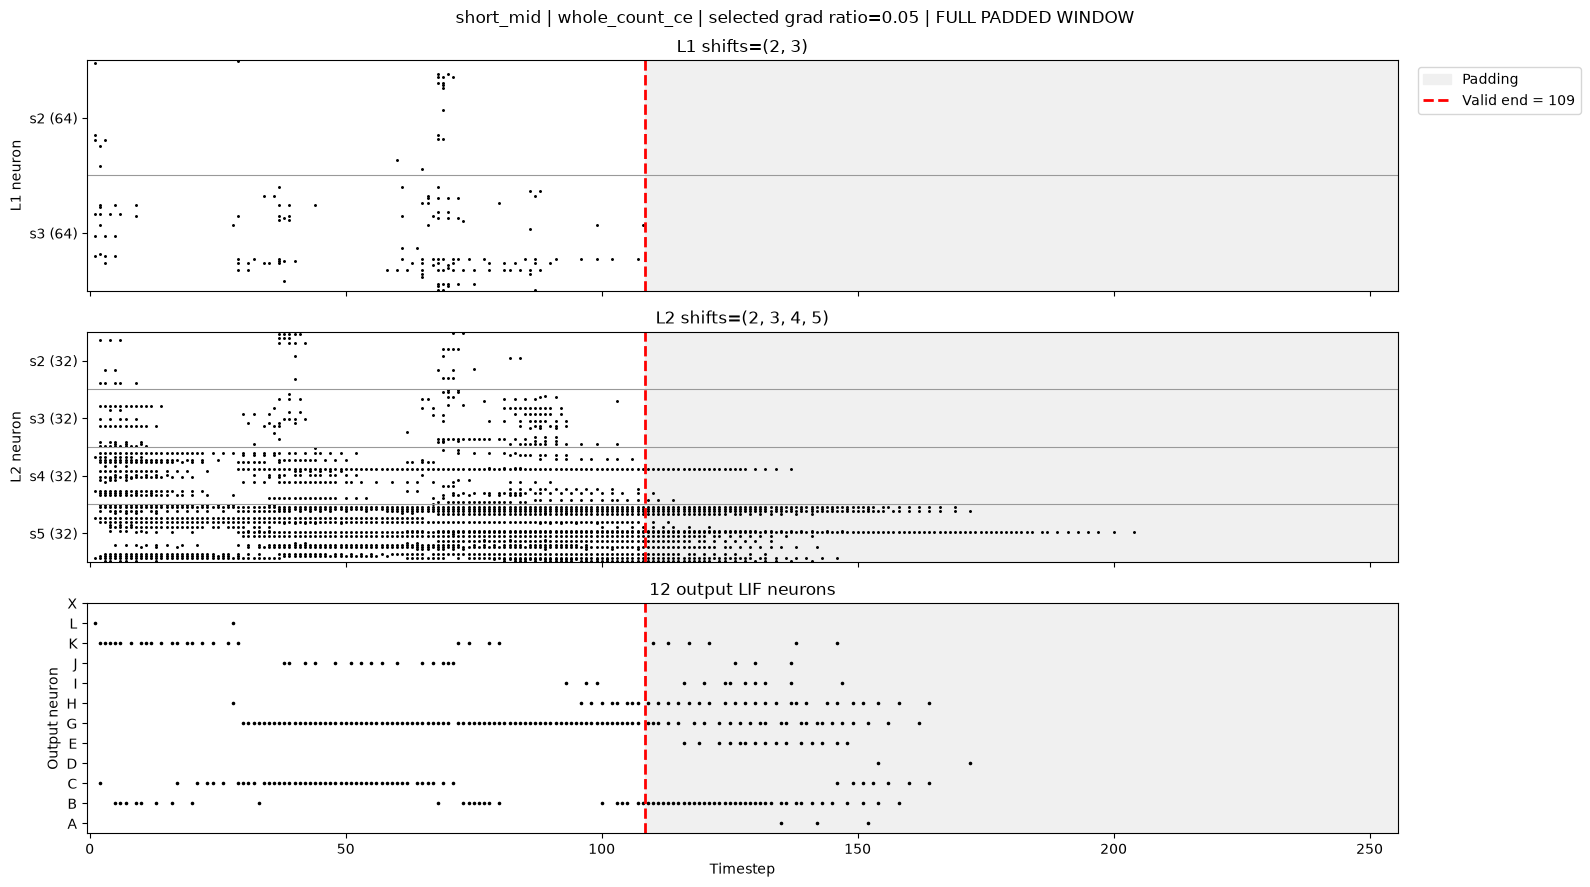

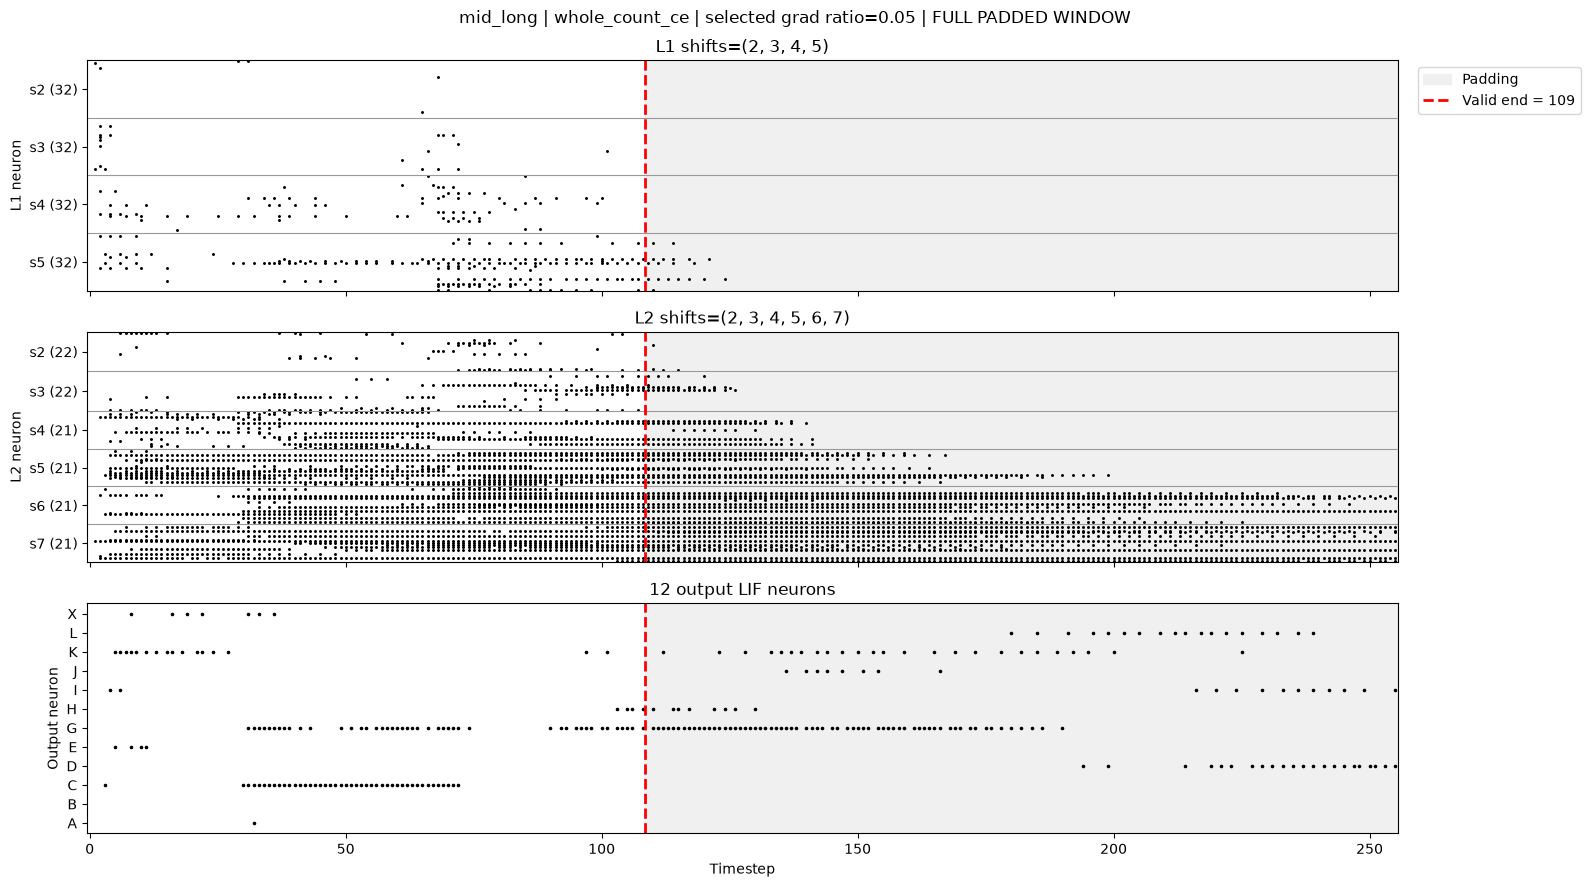

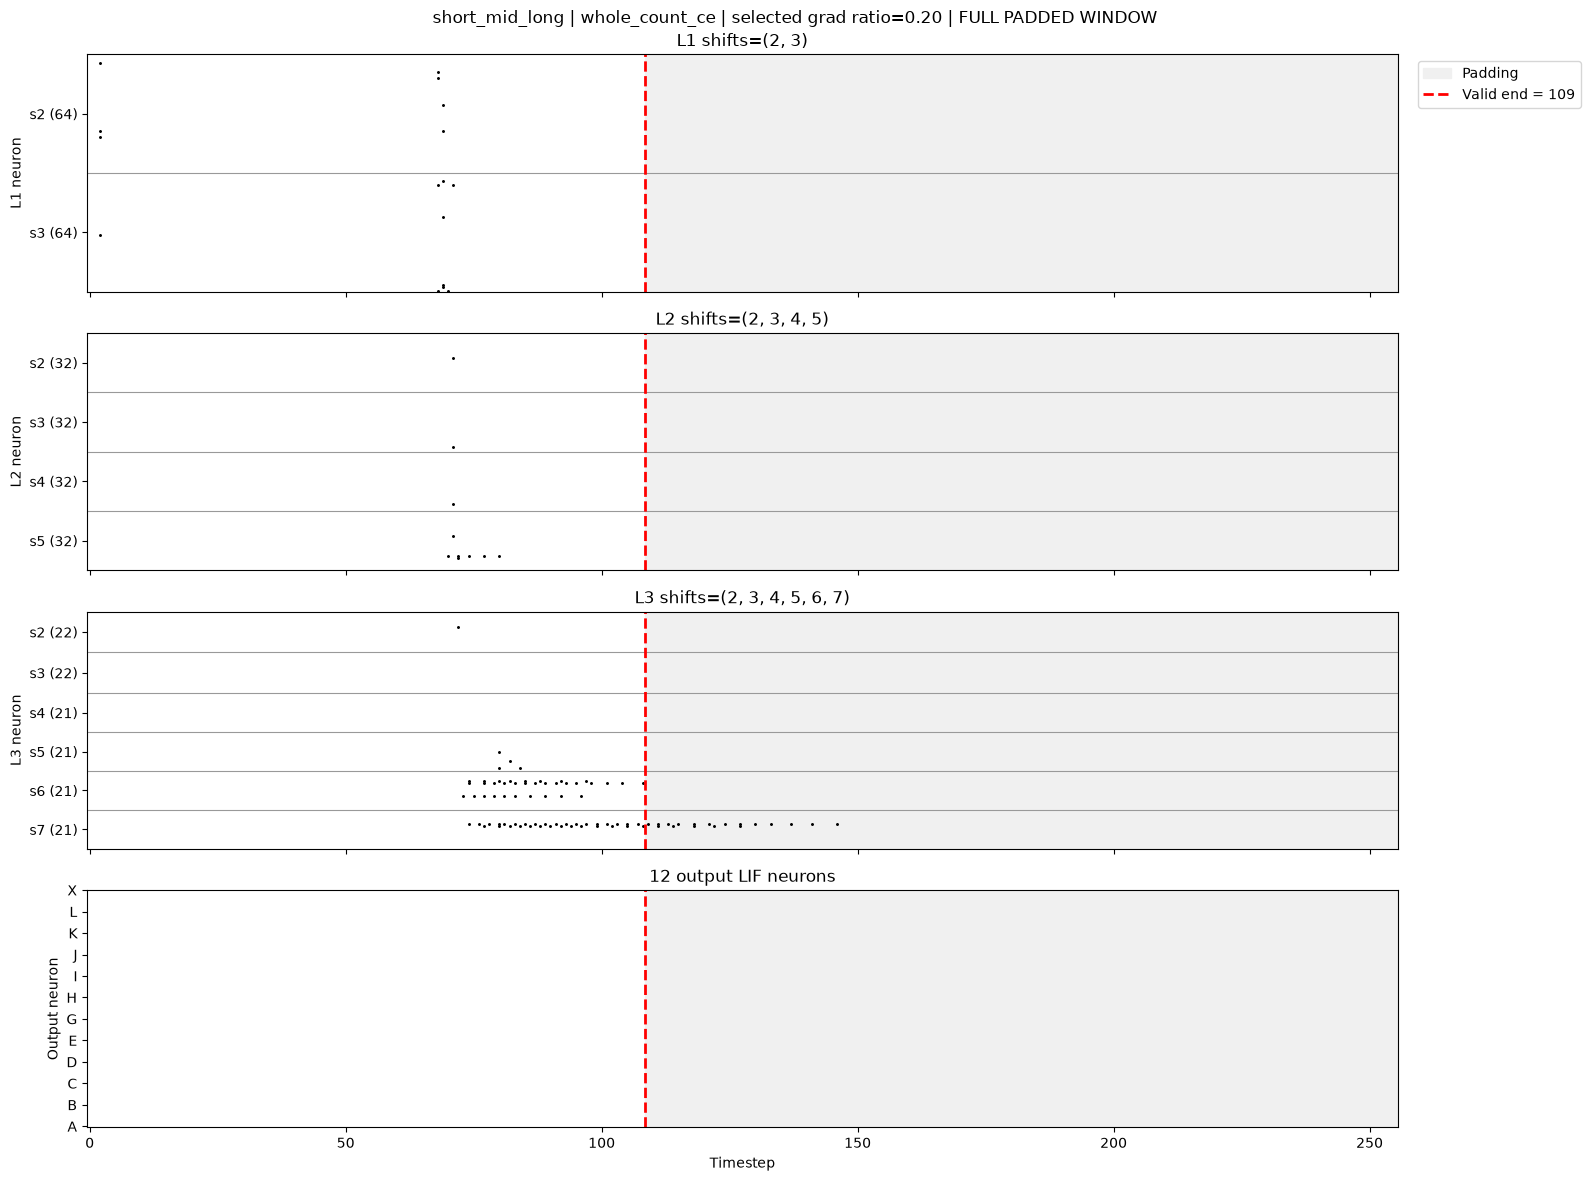

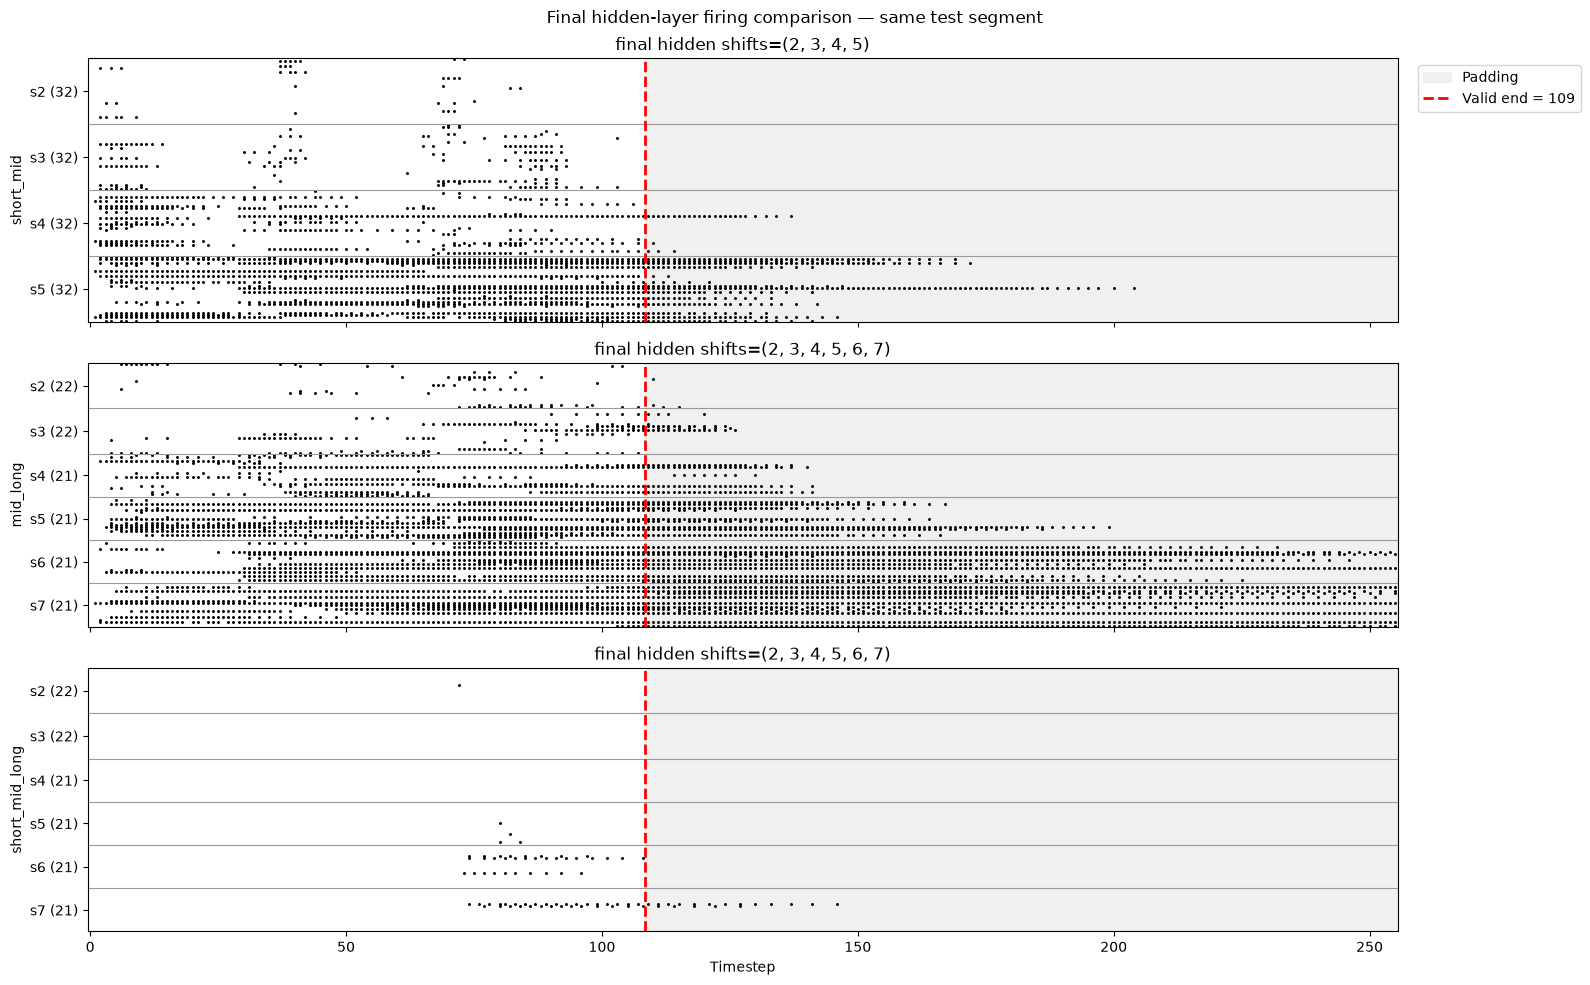

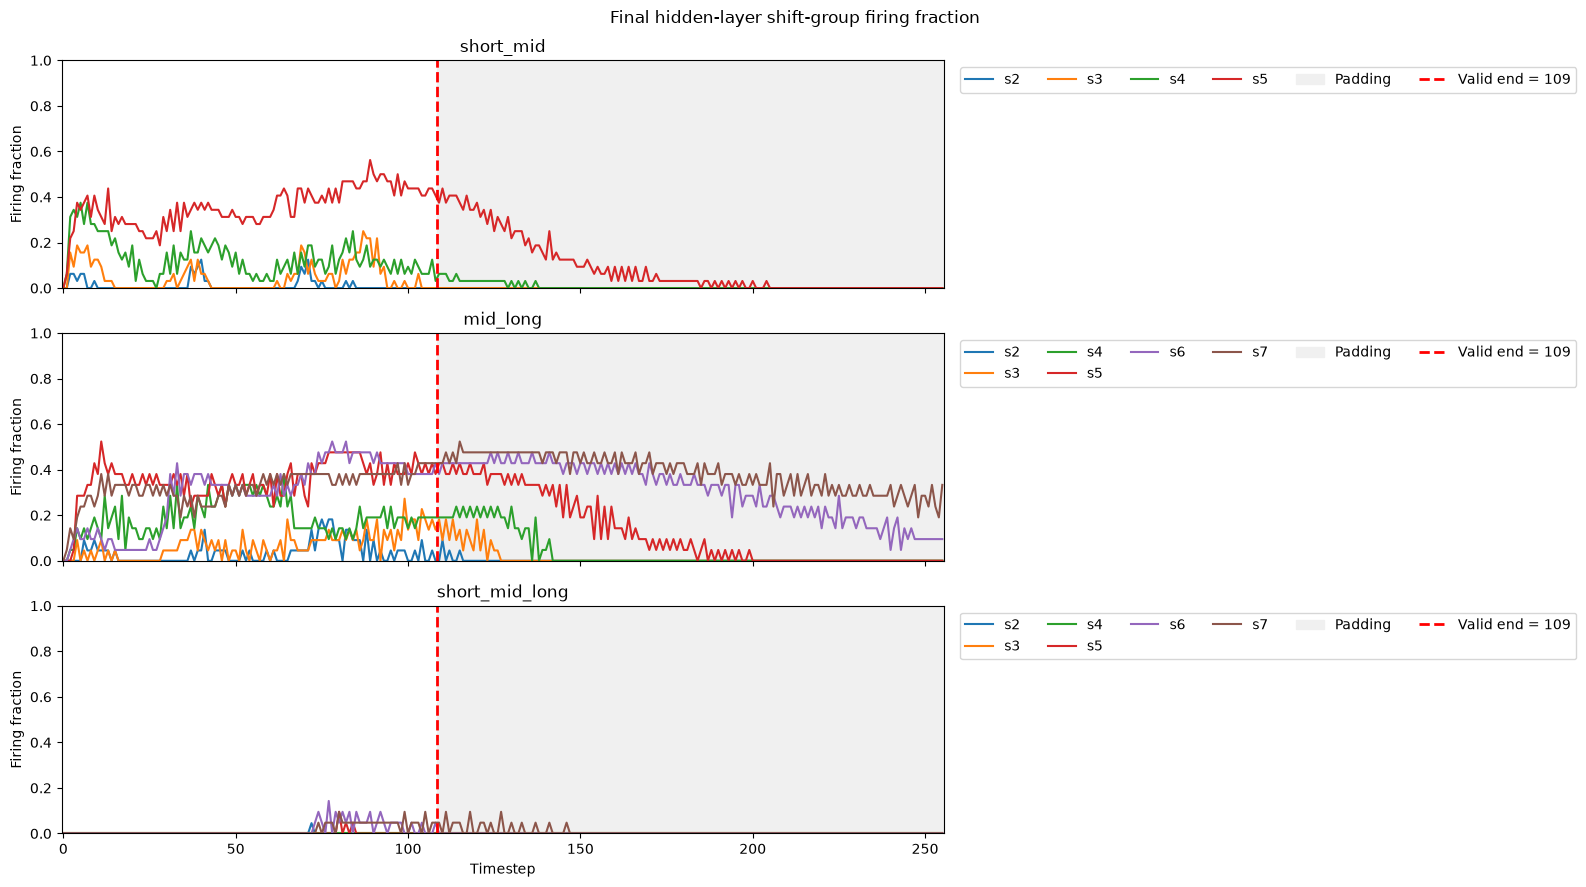

In [7]:
raster_figures = {architecture: plot_architecture_rasters(architecture) for architecture in ARCHITECTURES}
final_hidden_figure = plot_final_hidden_comparison()
group_firing_figure = plot_final_group_firing()
plt.show()

## Hidden-state heatmaps

These figures diagnose the proposed mechanism: long `tau_syn` can accumulate a large synaptic state `I`; despite fast membrane leak, persistent `I` can repeatedly drive `U^-` above threshold. Because hidden cap = 1, post-reset `U` may remain above threshold and the neuron can continue firing on subsequent timesteps.

/scratch/login/ipykernel_2509938/2309223645.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/scratch/login/ipykernel_2509938/2309223645.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/scratch/login/ipykernel_2509938/2309223645.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/scratch/login/ipykernel_2509938/2309223645.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/scratch/login/ipykernel_2509938/2309223645.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/scratch/login/ipykernel_2509938/2309223645.py:82: UserWarning: This figure

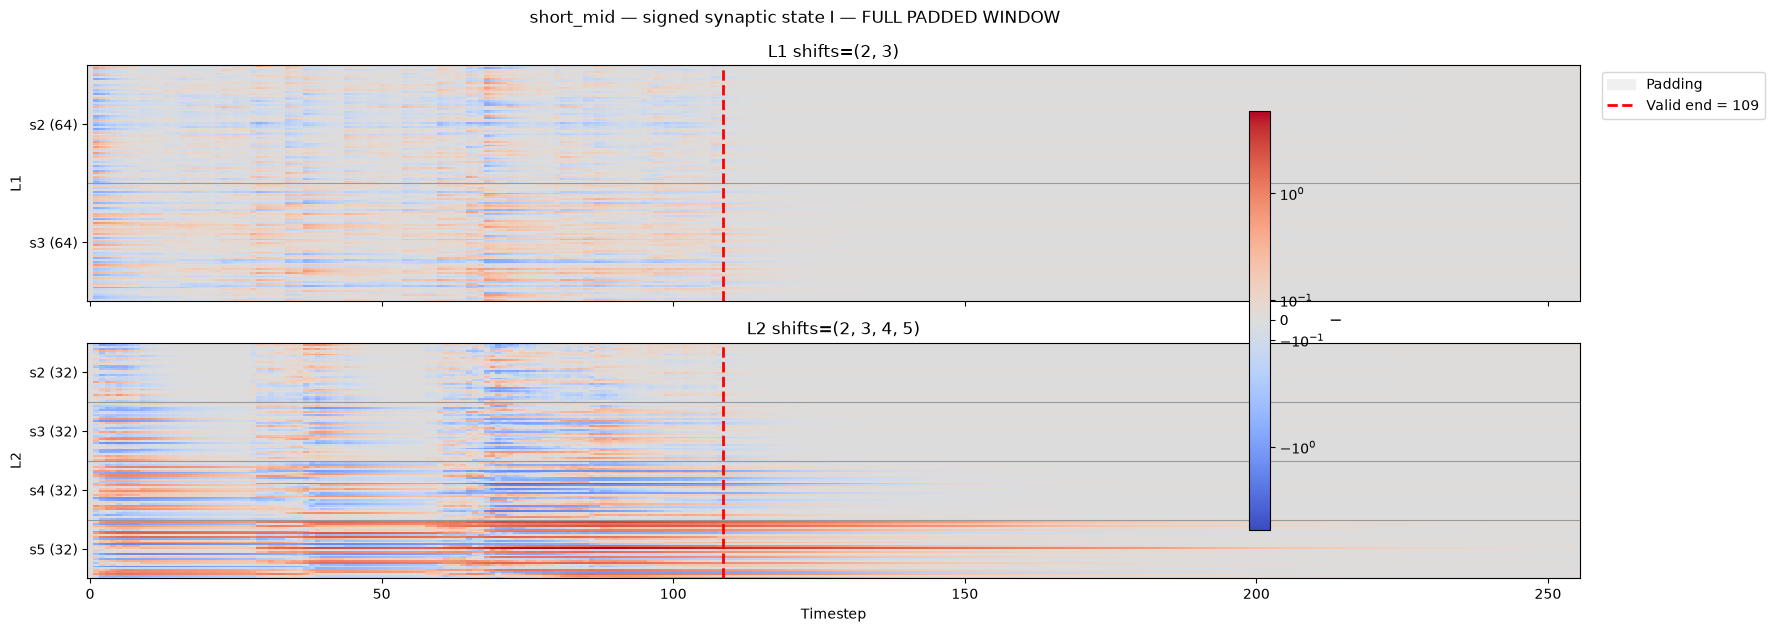

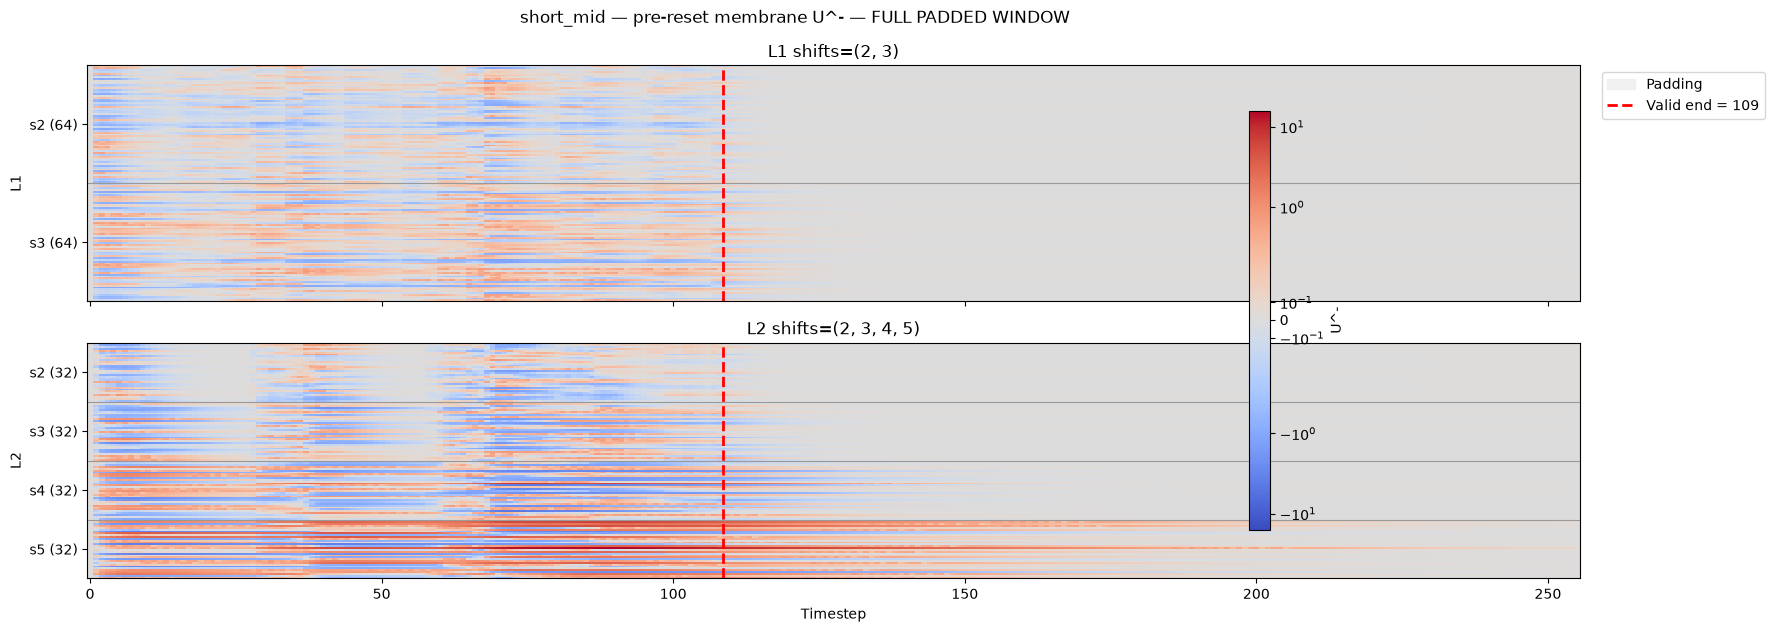

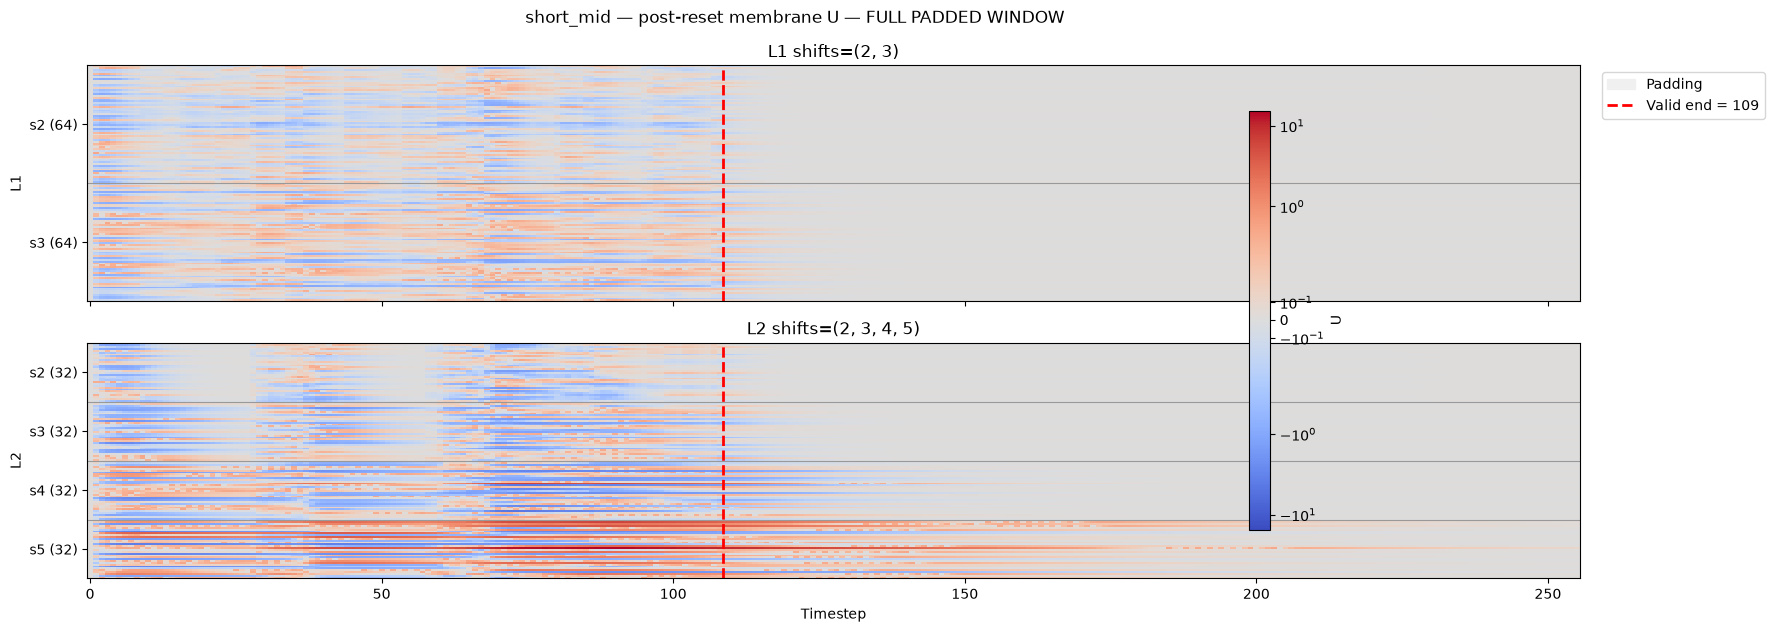

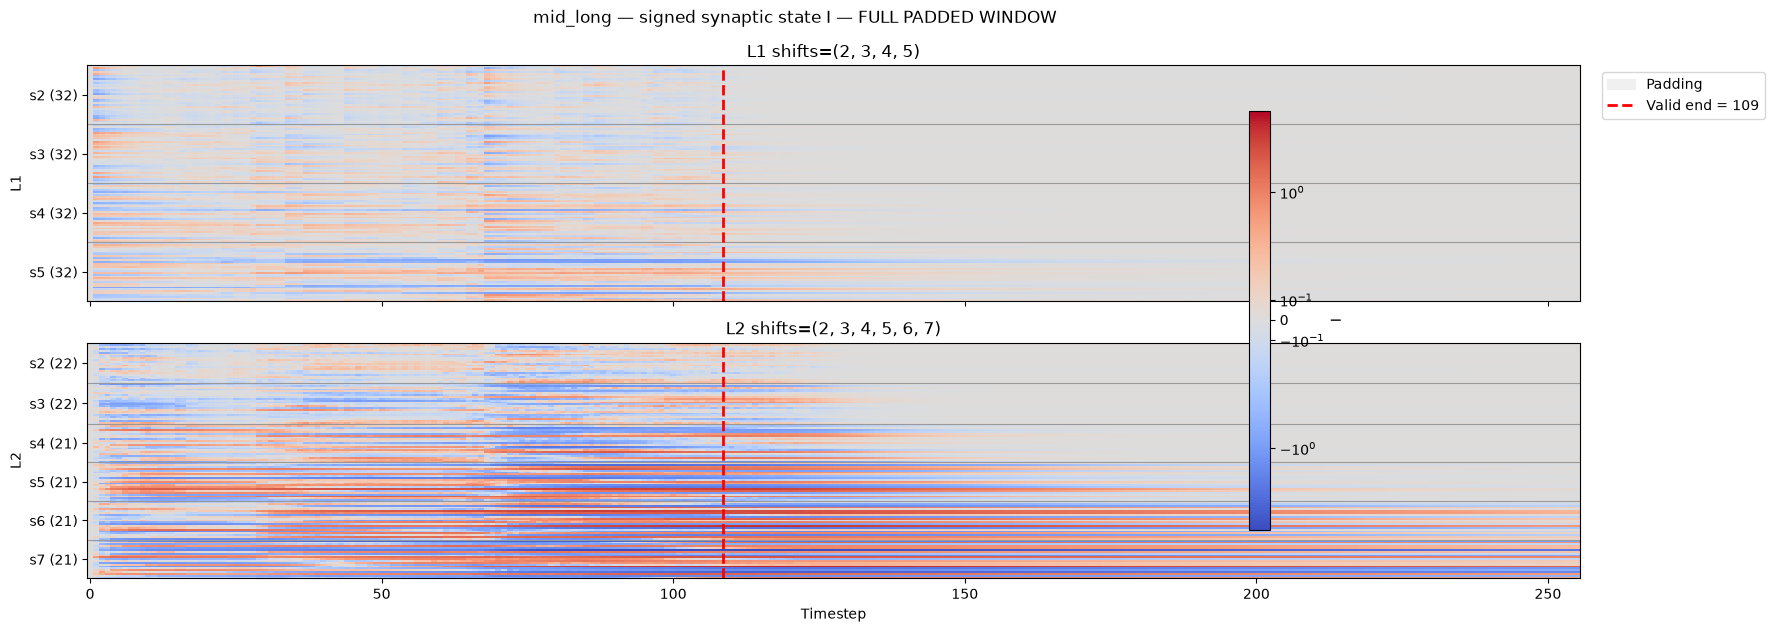

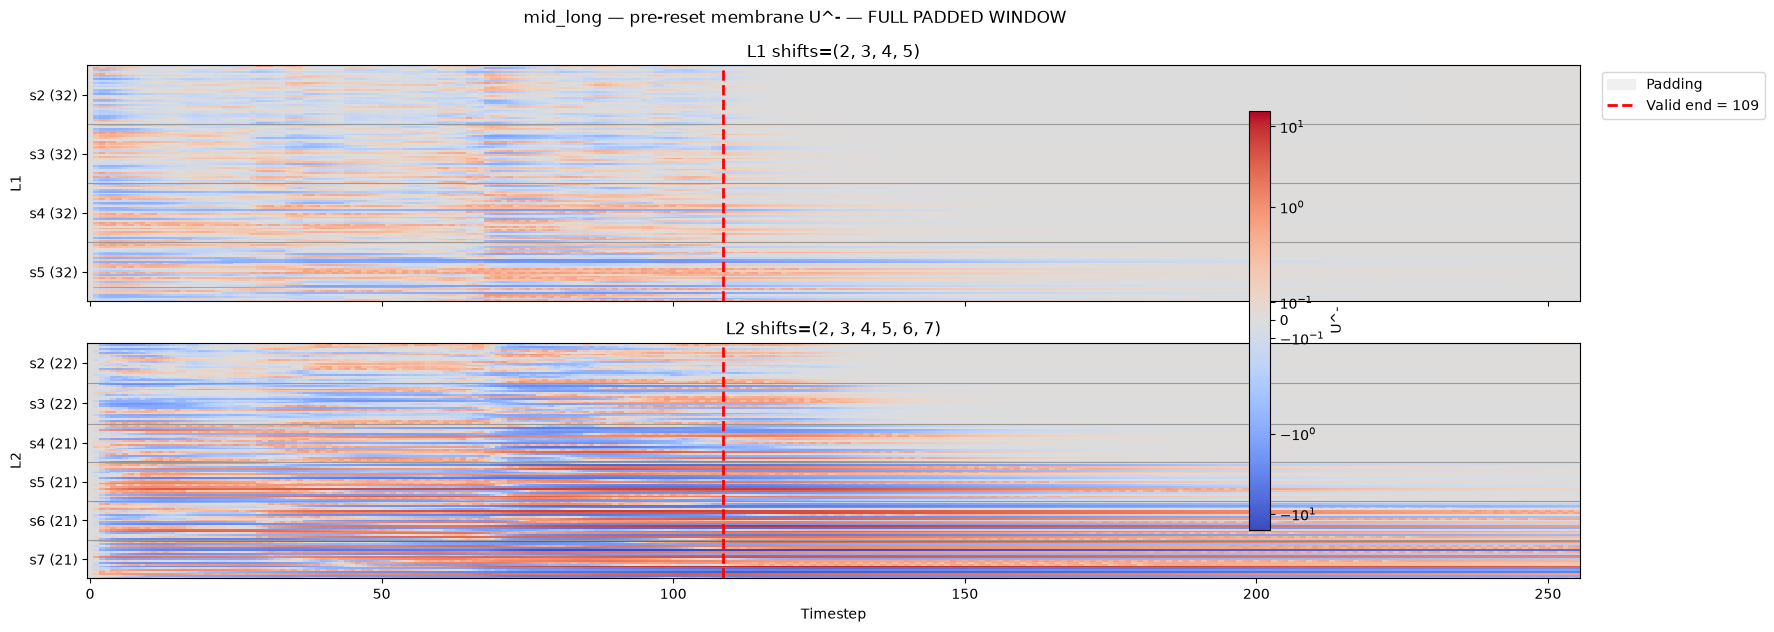

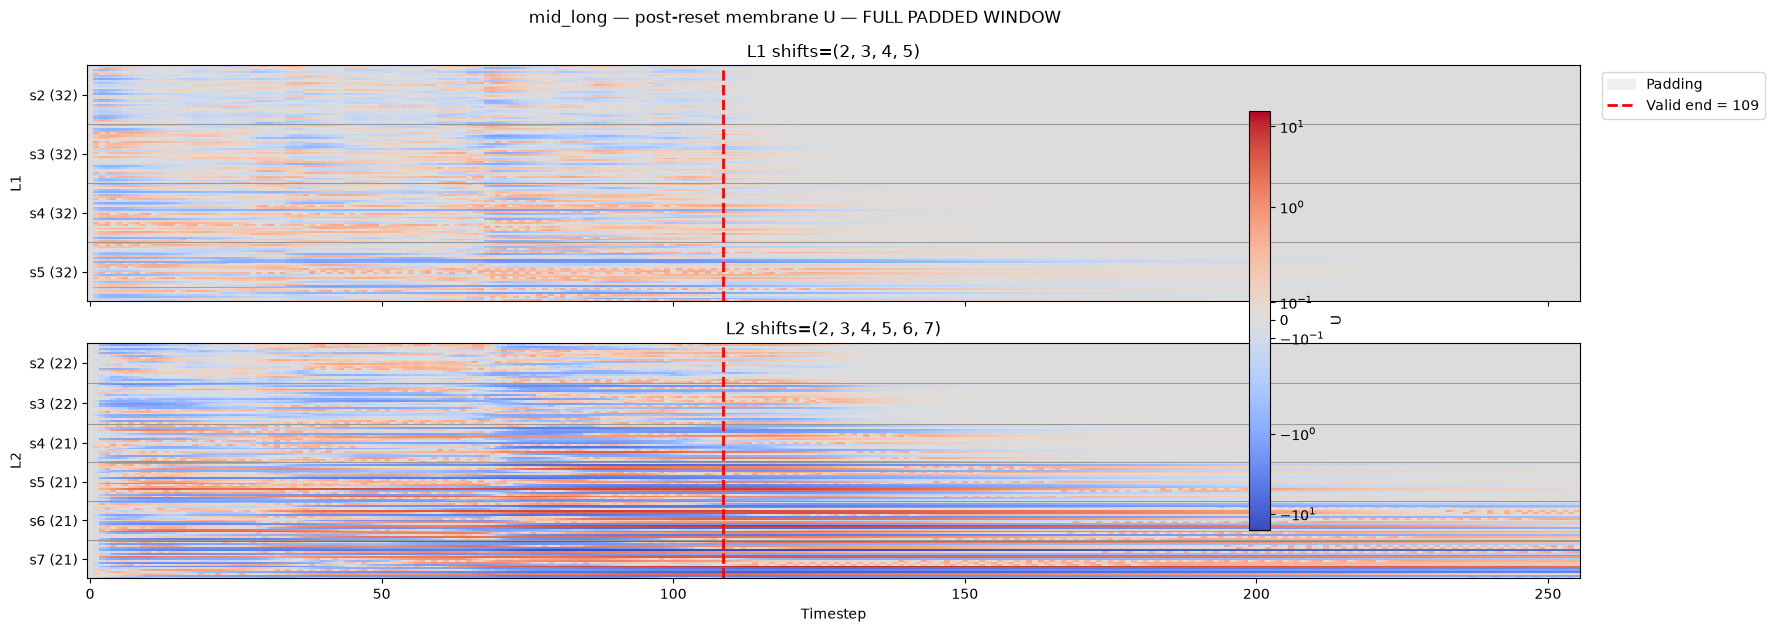

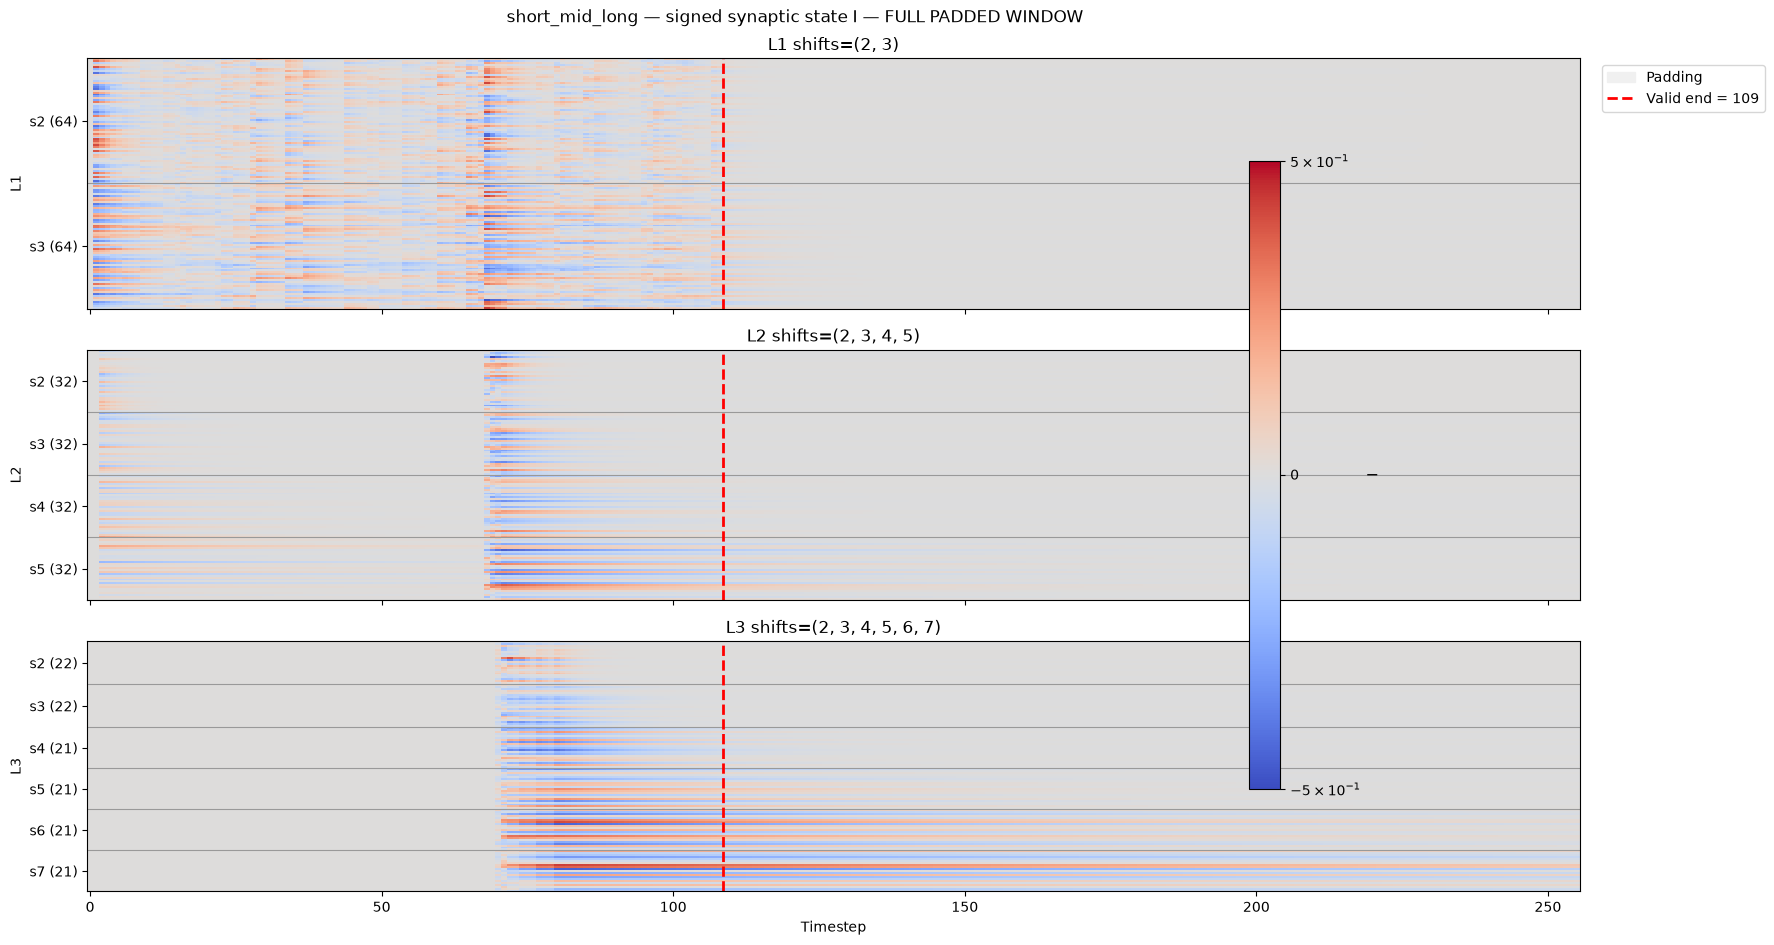

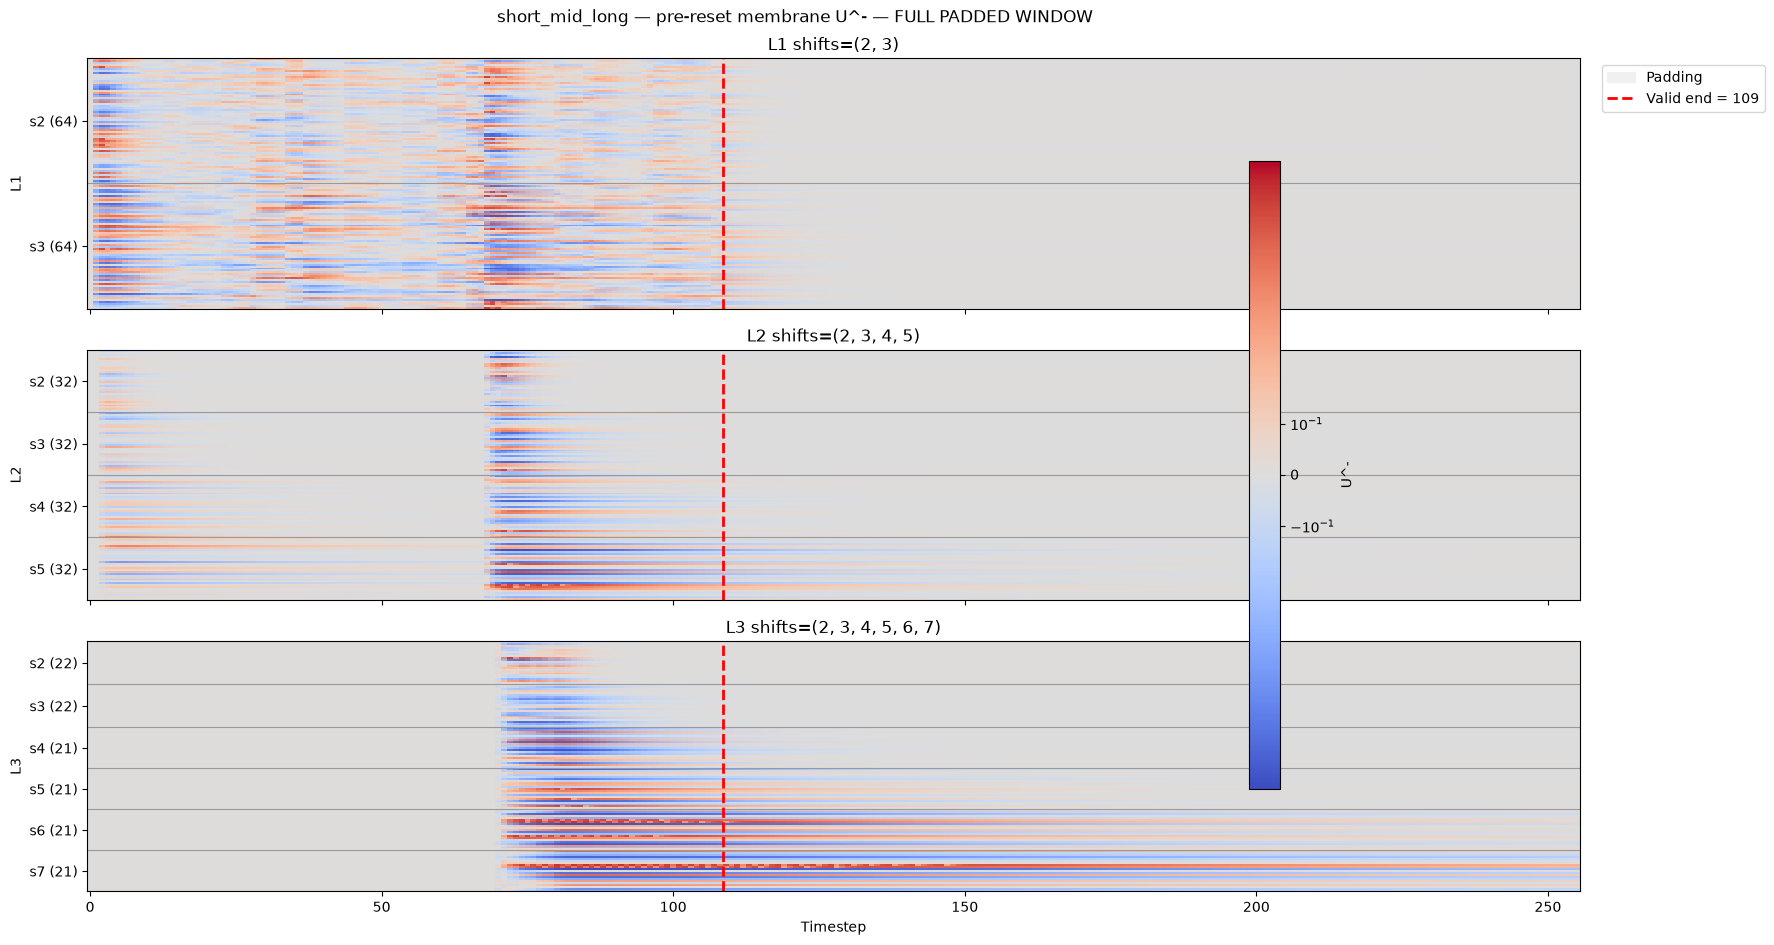

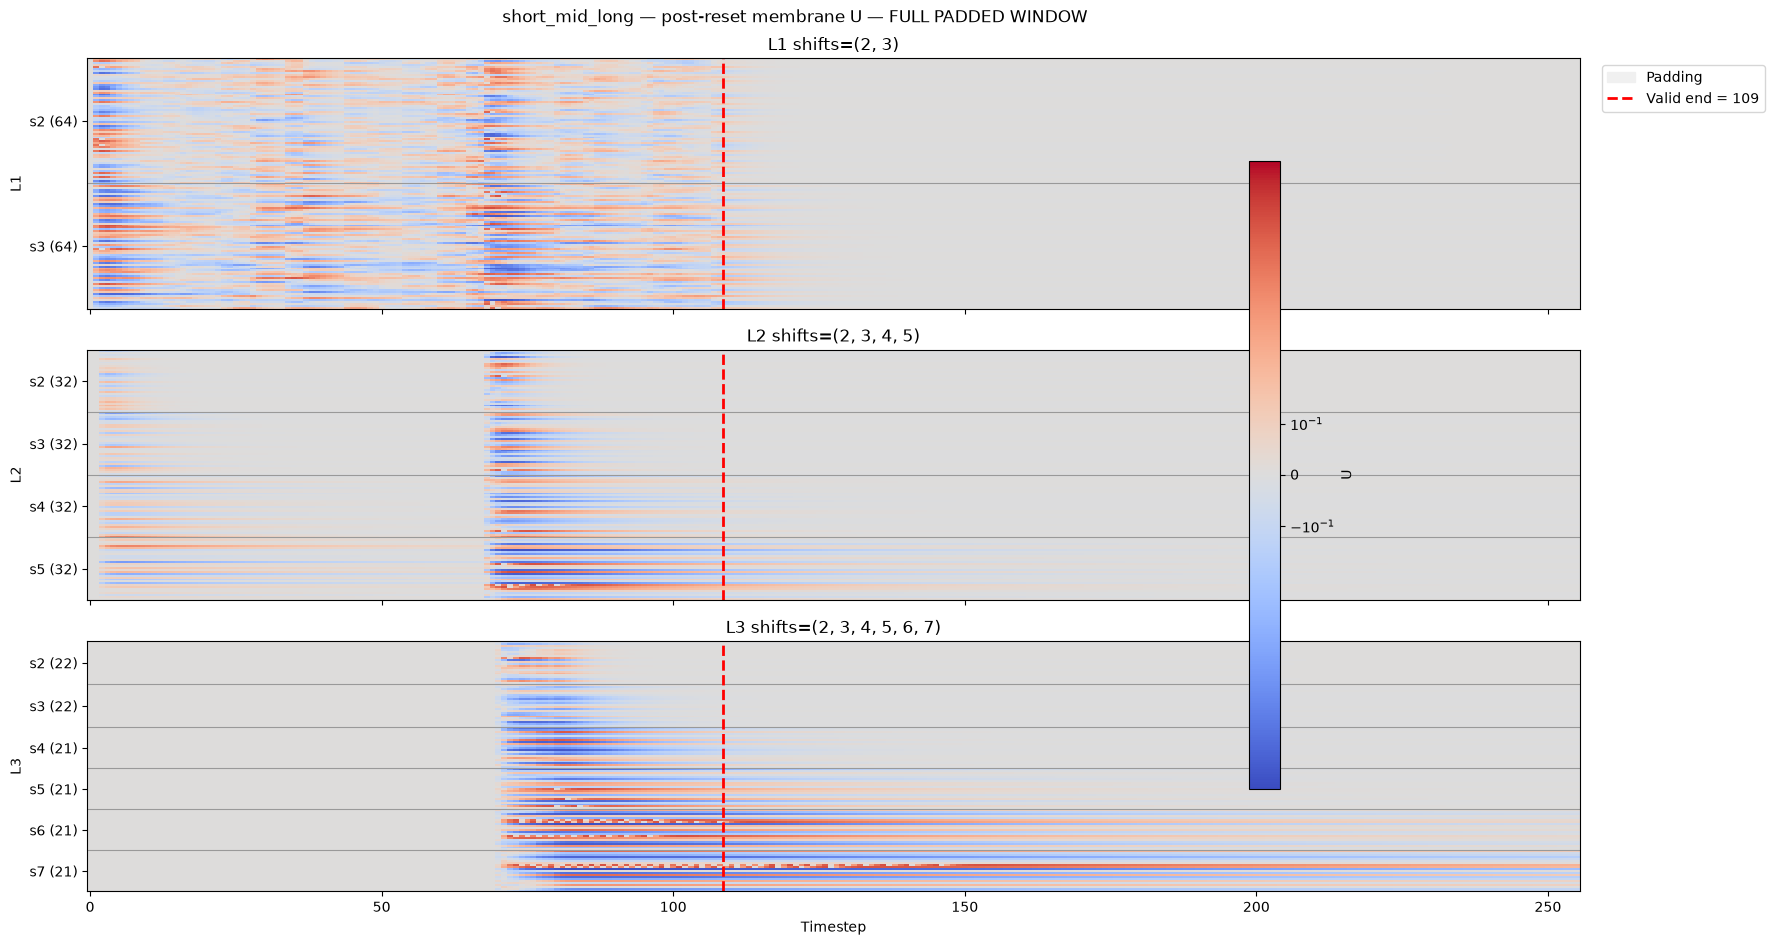

In [8]:
state_figures = {}
for architecture in ARCHITECTURES:
    state_figures[(architecture, 'I')] = plot_architecture_hidden_state(architecture, 'synaptic', 'signed synaptic state I', 'I')
    state_figures[(architecture, 'U_pre')] = plot_architecture_hidden_state(architecture, 'pre_membrane', 'pre-reset membrane U^-', 'U^-')
    state_figures[(architecture, 'U_post')] = plot_architecture_hidden_state(architecture, 'post_membrane', 'post-reset membrane U', 'U')
plt.show()

## Output-neuron activity

Top row: 12-neuron output spike raster. Bottom row: cumulative spike count across the full padded window. The valid-end line is the deployment boundary; counts to the right are shown only to diagnose residual dynamics.

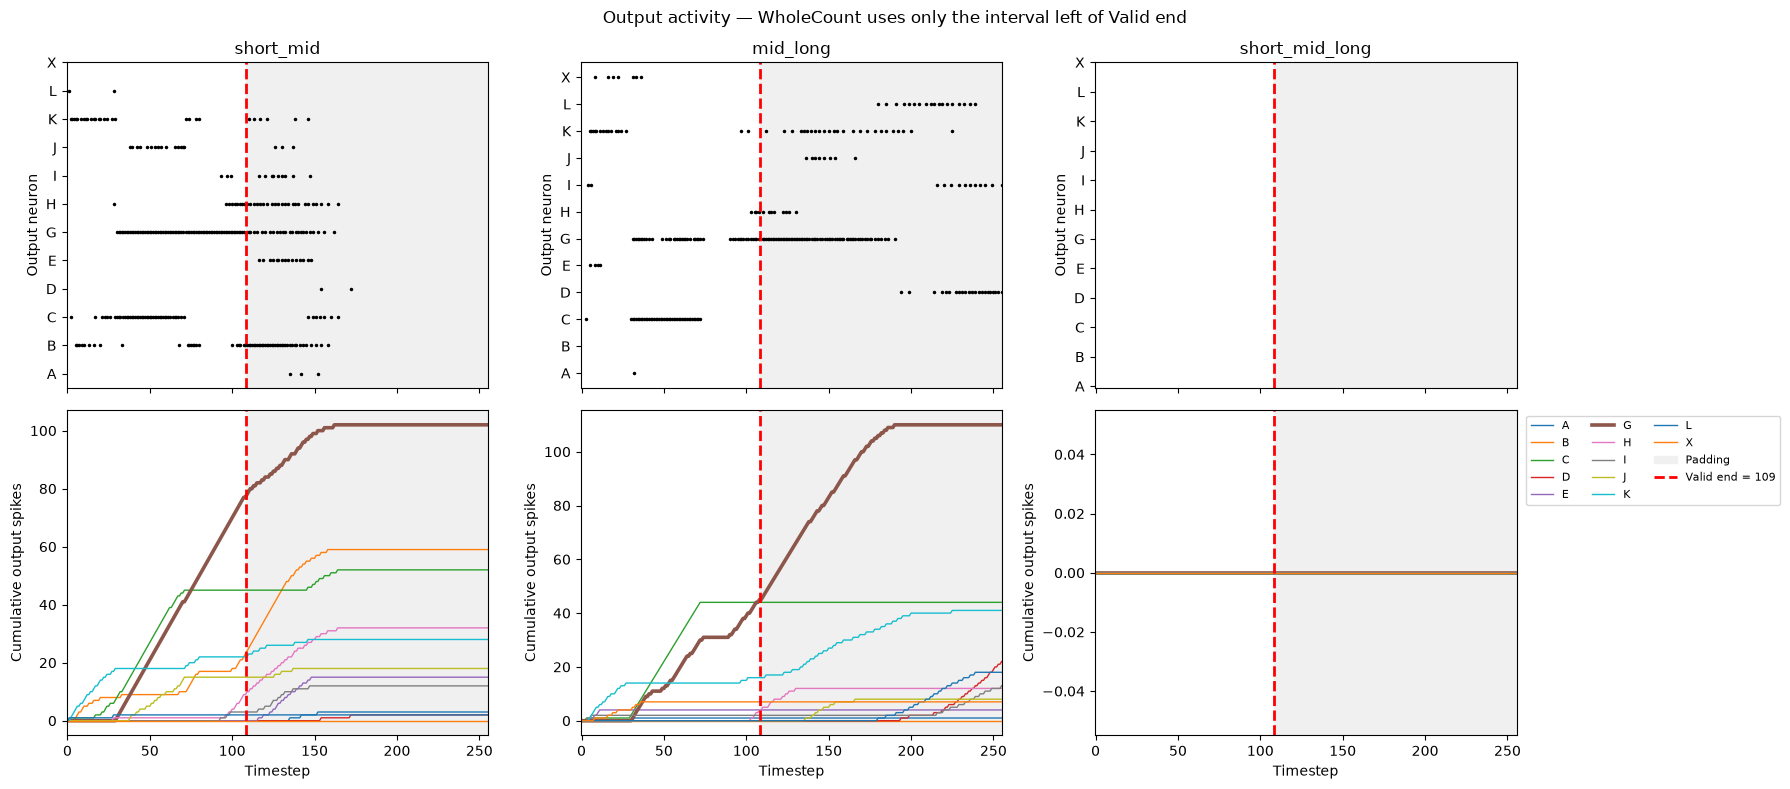

In [9]:
output_figure = plot_output_activity()
plt.show()

## Compact sustained-firing / backlog summary

This table is secondary to the raster plots. Statistics are computed separately by architecture, hidden layer, and shift group. `post_U_above_threshold_given_valid_spike` directly tests whether a neuron remains above threshold after already emitting its allowed binary spike for that timestep.

In [10]:
def consecutive_runs(binary):
    runs, current = [], 0
    for value in np.asarray(binary, dtype=bool):
        if value:
            current += 1
        elif current:
            runs.append(current)
            current = 0
    if current:
        runs.append(current)
    return runs

rows = []
threshold = float(exp015.exp01.THRESHOLD)
for architecture in ARCHITECTURES:
    for layer_index, shifts in enumerate(exp015.DIRECT_ARCHITECTURES[architecture]):
        layer = traces[architecture]['layers'][layer_index]
        spikes_all = layer['spikes'] > 0.5
        for shift, group in group_slices(shifts).items():
            spikes = spikes_all[:, group]
            valid_spikes = spikes[:valid_length]
            padding_spikes = spikes[valid_length:]
            per_neuron_valid_runs = [consecutive_runs(valid_spikes[:, neuron]) for neuron in range(valid_spikes.shape[1])]
            per_neuron_full_runs = [consecutive_runs(spikes[:, neuron]) for neuron in range(spikes.shape[1])]
            valid_max = [max(runs, default=0) for runs in per_neuron_valid_runs]
            full_max = [max(runs, default=0) for runs in per_neuron_full_runs]
            valid_positions = np.nonzero(valid_spikes)
            post_valid = layer['post_membrane'][:valid_length, group]
            backlog = np.nan if len(valid_positions[0]) == 0 else float(np.mean(post_valid[valid_positions] > threshold))
            total_spikes = int(spikes.sum())
            padding_spike_count = int(padding_spikes.sum())
            run_to_end_ge4 = float(np.mean(np.all(valid_spikes[-min(4, valid_length):], axis=0)))
            rows.append({
                'architecture': architecture,
                'layer': layer_index + 1,
                'shift': shift,
                'n_neurons': group.stop - group.start,
                'valid_firing_rate_hz': float(valid_spikes.mean() * data.fs),
                'padding_firing_rate_hz': float(padding_spikes.mean() * data.fs) if padding_spikes.size else np.nan,
                'padding_spike_fraction_of_full_window': padding_spike_count / max(total_spikes, 1),
                'mean_max_run_length_valid': float(np.mean(valid_max)),
                'max_run_length_valid': int(max(valid_max, default=0)),
                'max_run_length_full': int(max(full_max, default=0)),
                'fraction_neurons_run_ge8_valid': float(np.mean(np.asarray(valid_max) >= 8)),
                'fraction_neurons_firing_last4_valid_steps': run_to_end_ge4,
                'post_U_above_threshold_given_valid_spike': backlog,
                'valid_mean_signed_I': float(layer['synaptic'][:valid_length, group].mean()),
                'valid_mean_abs_I': float(np.abs(layer['synaptic'][:valid_length, group]).mean()),
                'valid_mean_abs_U_post': float(np.abs(layer['post_membrane'][:valid_length, group]).mean()),
                'endpoint_mean_abs_I': float(np.abs(layer['synaptic'][valid_length-1, group]).mean()),
                'endpoint_mean_abs_U_post': float(np.abs(layer['post_membrane'][valid_length-1, group]).mean()),
            })
activity_summary = pd.DataFrame(rows)
display(activity_summary)

print('\nFinal hidden layer only:')
final_rows = []
for architecture in ARCHITECTURES:
    final_layer = len(exp015.DIRECT_ARCHITECTURES[architecture])
    final_rows.append(activity_summary[(activity_summary.architecture == architecture) & (activity_summary.layer == final_layer)])
display(pd.concat(final_rows, ignore_index=True))

,architecture,layer,shift,n_neurons,valid_firing_rate_hz,padding_firing_rate_hz,padding_spike_fraction_of_full_window,mean_max_run_length_valid,max_run_length_valid,max_run_length_full,fraction_neurons_run_ge8_valid,fraction_neurons_firing_last4_valid_steps,post_U_above_threshold_given_valid_spike,valid_mean_signed_I,valid_mean_abs_I,valid_mean_abs_U_post,endpoint_mean_abs_I,endpoint_mean_abs_U_post
0,short_mid,1,2,64,0.201835,0.000000,0.000000,0.281250,2,2,0.000000,0.000000,0.000000,-0.017567,0.084123,0.152857,0.066669,0.121699
1,short_mid,1,3,64,1.174312,0.000000,0.000000,0.640625,3,3,0.000000,0.000000,0.000000,0.020188,0.125194,0.222864,0.102212,0.180596
2,short_mid,2,2,32,0.715596,0.000000,0.000000,0.812500,5,5,0.000000,0.000000,0.000000,-0.025106,0.097657,0.172822,0.062858,0.101987
3,short_mid,2,3,32,3.137615,0.000000,0.000000,2.843750,11,11,0.156250,0.000000,0.029240,-0.030958,0.176681,0.293373,0.117038,0.215450
4,short_mid,2,4,32,8.458716,0.380952,0.057260,8.093750,80,100,0.343750,0.031250,0.223427,-0.023533,0.345174,0.545306,0.278011,0.484733
5,short_mid,2,5,32,22.862385,5.632653,0.249398,30.531250,107,156,0.593750,0.375000,0.674960,0.367534,0.704305,1.035773,0.676203,0.973308
6,mid_long,1,2,32,0.110092,0.000000,0.000000,0.156250,1,1,0.000000,0.000000,0.000000,-0.027427,0.075611,0.137731,0.051688,0.099068
7,mid_long,1,3,32,0.366972,0.000000,0.000000,0.343750,2,2,0.000000,0.000000,0.000000,-0.002345,0.100936,0.185564,0.078828,0.142726
8,mid_long,1,4,32,1.449541,0.000000,0.000000,0.625000,2,2,0.000000,0.000000,0.000000,0.023359,0.138764,0.246644,0.103499,0.197110
9,mid_long,1,5,32,3.321101,0.258503,0.095000,0.906250,9,9,0.031250,0.000000,0.000000,-0.032219,0.205430,0.351329,0.198075,0.333871



Final hidden layer only:


,architecture,layer,shift,n_neurons,valid_firing_rate_hz,padding_firing_rate_hz,padding_spike_fraction_of_full_window,mean_max_run_length_valid,max_run_length_valid,max_run_length_full,fraction_neurons_run_ge8_valid,fraction_neurons_firing_last4_valid_steps,post_U_above_threshold_given_valid_spike,valid_mean_signed_I,valid_mean_abs_I,valid_mean_abs_U_post,endpoint_mean_abs_I,endpoint_mean_abs_U_post
0,short_mid,2,2,32,0.715596,0.000000,0.000000,0.812500,5,5,0.000000,0.000000,0.000000,-0.025106,0.097657,0.172822,0.062858,0.101987
1,short_mid,2,3,32,3.137615,0.000000,0.000000,2.843750,11,11,0.156250,0.000000,0.029240,-0.030958,0.176681,0.293373,0.117038,0.215450
2,short_mid,2,4,32,8.458716,0.380952,0.057260,8.093750,80,100,0.343750,0.031250,0.223427,-0.023533,0.345174,0.545306,0.278011,0.484733
3,short_mid,2,5,32,22.862385,5.632653,0.249398,30.531250,107,156,0.593750,0.375000,0.674960,0.367534,0.704305,1.035773,0.676203,0.973308
4,mid_long,2,2,22,2.215179,0.079159,0.045977,1.590909,8,8,0.090909,0.000000,0.000000,0.002279,0.144440,0.238938,0.128800,0.238010
5,mid_long,2,3,22,4.457048,0.791589,0.193237,3.863636,19,30,0.227273,0.090909,0.023952,-0.112720,0.260260,0.439007,0.295110,0.444837
6,mid_long,2,4,21,12.134557,2.425656,0.212341,12.904762,80,104,0.428571,0.190476,0.354839,-0.066886,0.443123,0.680570,0.551342,0.910780
7,mid_long,2,5,21,22.759284,8.209913,0.327273,30.333333,106,181,0.666667,0.333333,0.566339,0.068492,0.814659,1.252640,1.137105,1.895378
8,mid_long,2,6,21,18.872870,19.840622,0.586397,27.523810,81,226,0.523810,0.380952,0.749630,0.085216,0.851134,1.379361,1.447946,2.501240
9,mid_long,2,7,21,20.690258,24.795594,0.617769,29.333333,108,255,0.571429,0.428571,0.647297,-0.354598,1.124025,1.891267,1.876914,3.296227


## Valid-only WholeCount check

This is not a new BA experiment. It only reports the selected sample's original valid-only output counts and prediction for each frozen checkpoint.

In [11]:
wholecount_rows = []
for architecture in ARCHITECTURES:
    valid_counts = traces[architecture]['output']['spikes'][:valid_length].sum(axis=0)
    predicted = int(np.argmax(valid_counts))
    wholecount_rows.append({
        'architecture': architecture,
        'target_grad_ratio': selected[architecture]['spec'].target_grad_ratio,
        'true_label': data.labels[int(y[sample_index])],
        'prediction': data.labels[predicted],
        'correct': predicted == int(y[sample_index]),
        'winning_valid_count': float(valid_counts[predicted]),
        'true_class_valid_count': float(valid_counts[int(y[sample_index])]),
    })
display(pd.DataFrame(wholecount_rows))

,architecture,target_grad_ratio,true_label,prediction,correct,winning_valid_count,true_class_valid_count
0,short_mid,0.05,G,G,True,77.0,77.0
1,mid_long,0.05,G,G,True,45.0,45.0
2,short_mid_long,0.20,G,A,False,0.0,0.0


## Optional figure export

Saving is disabled by default. If enabled, figures are written under the Exp0.1.5 artifact root in a dedicated diagnostic directory; no training artifacts are modified.

In [12]:
if SAVE_FIGURES:
    out_dir = results_root / 'wholecount_firing_pattern_diagnostic' / f'seed{SEED}' / f'test_sample{sample_index:04d}'
    out_dir.mkdir(parents=True, exist_ok=True)
    for architecture, fig in raster_figures.items():
        fig.savefig(out_dir / f'{architecture}__all_rasters.png', dpi=180, bbox_inches='tight')
    final_hidden_figure.savefig(out_dir / 'final_hidden_comparison.png', dpi=180, bbox_inches='tight')
    group_firing_figure.savefig(out_dir / 'final_hidden_group_firing.png', dpi=180, bbox_inches='tight')
    output_figure.savefig(out_dir / 'output_activity.png', dpi=180, bbox_inches='tight')
    for (architecture, state_name), fig in state_figures.items():
        fig.savefig(out_dir / f'{architecture}__{state_name}.png', dpi=180, bbox_inches='tight')
    activity_summary.to_csv(out_dir / 'activity_summary.csv', index=False)
    selection_table.to_csv(out_dir / 'checkpoint_selection.csv', index=False)
    print('saved to:', out_dir)
else:
    print('SAVE_FIGURES=False; nothing written')

SAVE_FIGURES=False; nothing written


## Interpretation guide

The strongest support for a long-synaptic-state backlog mechanism would be: (1) `mid_long` / `short_mid_long` shifts 6/7 develop long horizontal spike bands during the valid interval; (2) signed `I` remains large while `U` repeatedly crosses threshold; (3) post-reset `U` often remains above threshold despite a spike; and (4) the same neurons continue firing into padding even though padding is excluded from WholeCount loss. The padding tail is therefore a diagnostic symptom, not itself part of the trained classifier objective.